In [15]:

# %conda install -c conda-forge poppler
# %pip install pdf2image timm transformers

In [16]:

from pdf2image import convert_from_path, convert_from_bytes
from pdf2image.exceptions import (
    PDFInfoNotInstalledError,
    PDFPageCountError,
    PDFSyntaxError
)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch


In [17]:
images = convert_from_path('DON-0001_1.pdf')


In [18]:
class UnionFind:
    def __init__(self, n):
        # Khởi tạo cấu trúc Union-Find với n phần tử
        self.parent = list(range(n))
        self.rank = [0] * n
    
    def find(self, x):
        # Tìm gốc của phần tử x với nén đường (path compression)
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x, y):
        # Hợp nhất hai phần tử x và y
        px, py = self.find(x), self.find(y)
        if px == py:
            return
        if self.rank[px] < self.rank[py]:
            self.parent[px] = py
        elif self.rank[px] > self.rank[py]:
            self.parent[py] = px
        else:
            self.parent[py] = px
            self.rank[px] += 1

def merge_horizontal_boxes(boxes, threshold=10):
    n = len(boxes)
    if n == 0:
        return []
    
    # Khởi tạo Union-Find cho n box
    uf = UnionFind(n)
    
    # Sắp xếp các box theo tọa độ x1 để tối ưu hóa việc kiểm tra
    sorted_indices = sorted(range(n), key=lambda i: boxes[i][0])
    
    # Kiểm tra từng cặp box để xác định liền kề
    for i in range(n):
        idx_i = sorted_indices[i]
        x1_i, y1_i, x2_i, y2_i = boxes[idx_i]
        j = i + 1
        while j < n:
            idx_j = sorted_indices[j]
            x1_j, y1_j, x2_j, y2_j = boxes[idx_j]
            # Thoát vòng lặp nếu box j quá xa box i theo chiều ngang
            if x1_j >= x2_i + threshold:
                break
            # Kiểm tra nếu hai box liền kề: y giao nhau và khoảng cách x nhỏ hơn threshold
            if max(y1_i, y1_j) < min(y2_i, y2_j) and (x1_j - x2_i < threshold):
                uf.union(idx_i, idx_j)
            j += 1
    
    # Nhóm các box theo gốc của chúng trong Union-Find
    from collections import defaultdict
    groups = defaultdict(list)
    for i in range(n):
        root = uf.find(i)
        groups[root].append(boxes[i])
    
    # Gộp các box trong mỗi nhóm thành một box duy nhất
    merged_boxes = []
    for group in groups.values():
        min_x1 = min(box[0] for box in group)
        min_y1 = min(box[1] for box in group)
        max_x2 = max(box[2] for box in group)
        max_y2 = max(box[3] for box in group)
        merged_boxes.append([min_x1, min_y1, max_x2, max_y2])
    
    return merged_boxes



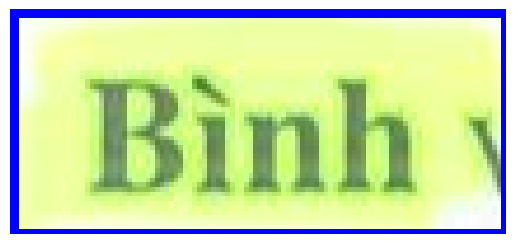

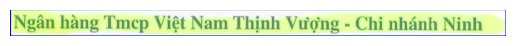

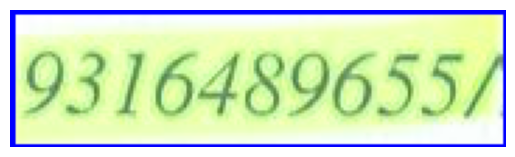

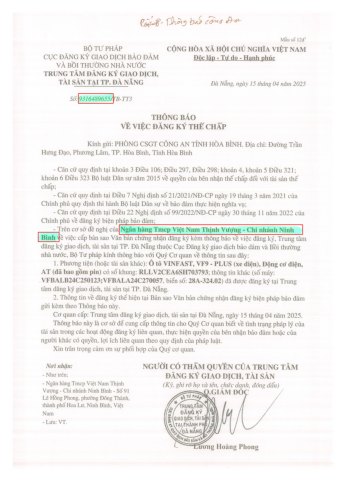

In [19]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Giả sử bạn đã có ảnh image dưới dạng BGR (ví dụ như từ images[26])
image = np.array(images[24])

# Chuyển sang không gian màu HSV để dễ tách màu xanh lá
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Định nghĩa ngưỡng màu xanh lá cây
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# Tạo mask cho vùng màu xanh lá
mask = cv2.inRange(hsv, lower_green, upper_green)

# Tìm contours trong mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Thu thập danh sách bounding box từ contours
boxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w * h > 100:  # Bỏ qua các vùng nhỏ
        boxes.append([x, y, x + w, y + h])  # Lưu dưới dạng [x1, y1, x2, y2]

# Gộp các bounding box liền kề theo chiều ngang
# Giả sử bạn đã có hàm merge_horizontal_boxes được định nghĩa
merged_boxes = merge_horizontal_boxes(boxes, threshold=15)

highlighted_green = []
# Tô đỏ các vùng bounding box đã gộp
for box in merged_boxes:
    x1, y1, x2, y2 = box
    # Draw a red rectangle (BGR: (0, 0, 255)) with a thickness of 2 pixels
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
    highlighted_green.append(image[y1:y2, x1:x2])
    plt.imshow(image[y1:y2, x1:x2])
    plt.axis('off') 
    plt.show()

# Hiển thị kết quả
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()



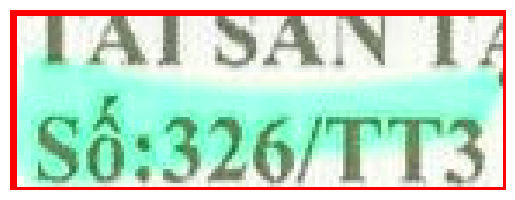

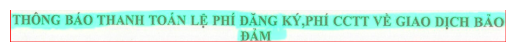

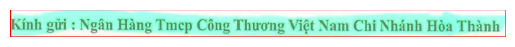

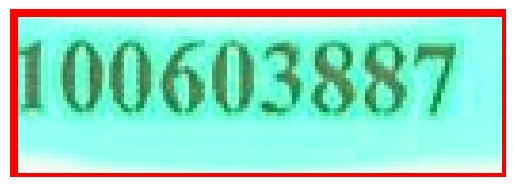

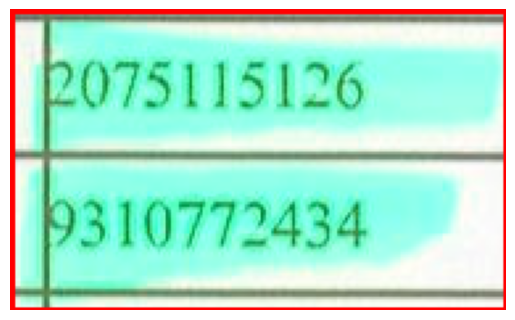

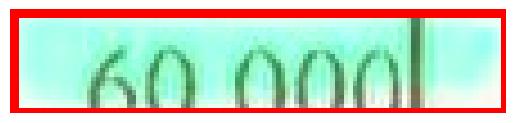

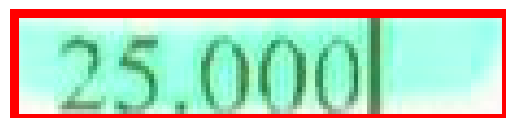

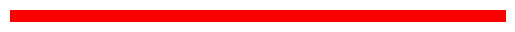

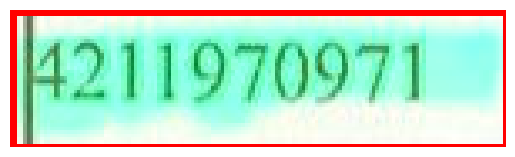

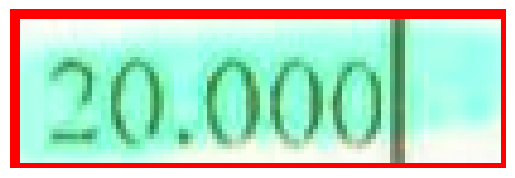

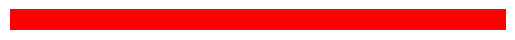

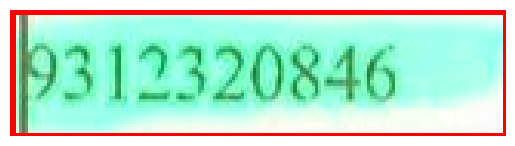

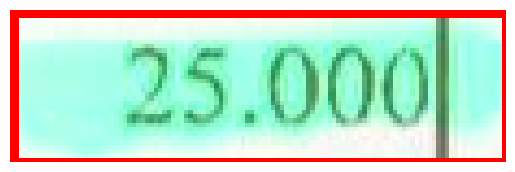

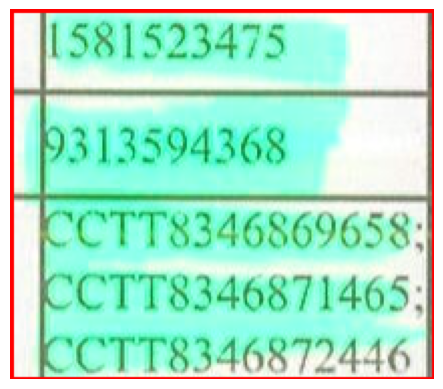

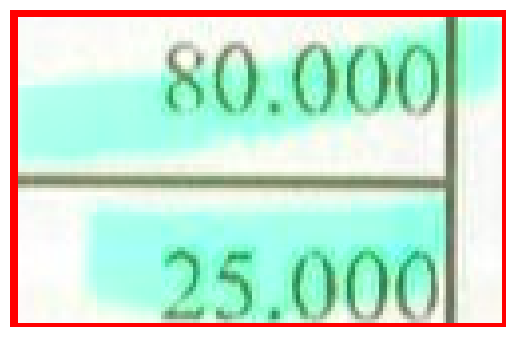

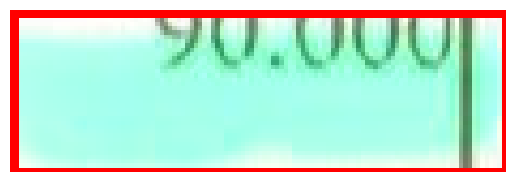

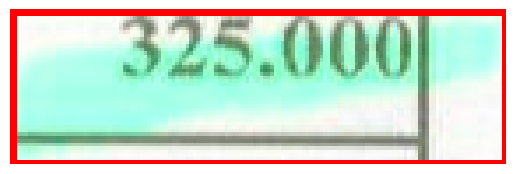

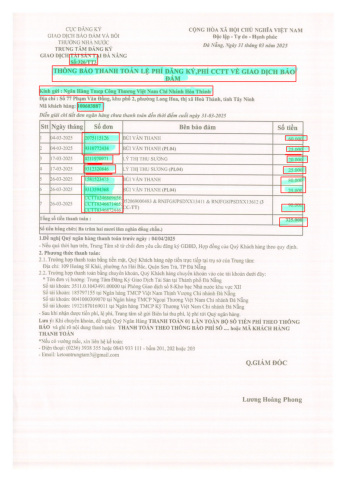

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Giả sử bạn đã có ảnh image dưới dạng BGR (ví dụ như từ images[26])
image = np.array(images[26])

# Chuyển sang không gian màu HSV để dễ tách màu xanh lá
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Định nghĩa ngưỡng màu xanh lá cây
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# Tạo mask cho vùng màu xanh lá
mask = cv2.inRange(hsv, lower_green, upper_green)

# Tìm contours trong mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Thu thập danh sách bounding box từ contours và sắp xếp theo y1 (từ trên xuống dưới)
boxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w * h > 100:  # Bỏ qua các vùng nhỏ
        boxes.append([x, y, x + w, y + h])  # Lưu dưới dạng [x1, y1, x2, y2]

# Sắp xếp boxes theo tọa độ y1 (từ trên xuống dưới)
boxes.sort(key=lambda b: b[1])

# Gộp các bounding box liền kề theo chiều ngang
# Giả sử bạn đã có hàm merge_horizontal_boxes được định nghĩa
merged_boxes = merge_horizontal_boxes(boxes, threshold=15)

# Sắp xếp lại merged_boxes theo y1 để đảm bảo thứ tự từ trên xuống dưới
merged_boxes.sort(key=lambda b: b[1])

highlighted_green = []
# Tô đỏ các vùng bounding box đã gộp và lưu vào highlighted_green
for box in merged_boxes:
    x1, y1, x2, y2 = box
    # Vẽ hình chữ nhật màu đỏ (BGR: (0, 0, 255)) với độ dày 2 pixel
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
    highlighted_green.append(image[y1:y2, x1:x2])
    plt.imshow(cv2.cvtColor(image[y1:y2, x1:x2], cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Hiển thị ảnh gốc với các vùng đã khoanh
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [21]:
# from ultralytics import YOLO
# import torch

# highlighted_green = []
# # Tô đỏ các vùng bounding box đã gộp và lưu vào highlighted_green
# for box in merged_boxes:
#     x1, y1, x2, y2 = box
#     # Vẽ hình chữ nhật màu đỏ (BGR: (0, 0, 255)) với độ dày 2 pixel
#     cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
#     highlighted_green.append(image[y1:y2, x1:x2])
#     detect = YOLO('yolov8-highlight-detect.pt')
#     plt.imshow(cv2.cvtColor(image[y1:y2, x1:x2], cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.show()

# # Hiển thị ảnh gốc với các vùng đã khoanh
# plt.figure(figsize=(10, 6))
# plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()

In [22]:
import numpy as np
import torch
import torchvision.transforms as T
# from decord import VideoReader, cpu
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = image_file.convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

model = AutoModel.from_pretrained(
    "5CD-AI/Vintern-1B-v3_5",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    use_flash_attn=False,
).eval().cuda()

tokenizer = AutoTokenizer.from_pretrained("5CD-AI/Vintern-1B-v3_5", trust_remote_code=True, use_fast=False)


/home/duckq1u/miniconda3/envs/OCR/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/duckq1u/miniconda3/envs/OCR/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Sliding Window Attention is enabled but not implemented for `eager`; unexpected results may be encountered.


FlashAttention2 is not installed.


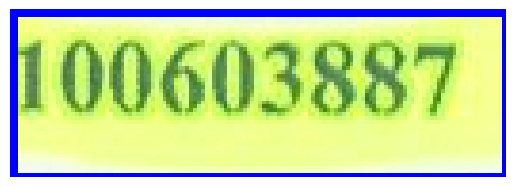

In [23]:
img2 = Image.fromarray(highlighted_green[3])
plt.imshow(img2)
plt.axis('off')
plt.show()

In [24]:
pixel_values = load_image(img2, max_num=6).to(torch.bfloat16).cuda()
generation_config = dict(max_new_tokens= 1024, do_sample=False, num_beams = 3, repetition_penalty=2.5)

question = '<image>\ntrích xuất thông tin'

response, history = model.chat(tokenizer, pixel_values, question, generation_config, history=None, return_history=True)
print(f'{response}')

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


100603887
